# ROM Material Parameter Identification -- Pipeline Walkthrough

This notebook walks through the `romid` package end to end: loading a pre-built
POD + RBF reduced-order model, identifying a tensile specimen's shear modulus
(G) and bulk modulus (K) from real DIC displacement data, and visualizing the
result. See the top-level [README](../README.md) for the project pitch and
[docs/theory.md](../docs/theory.md) for the full mathematical formulation.

Everything below runs against the small pre-built artifacts in `data/sample/`
and needs only `pip install -e ..` (or `pip install -e "..[app]"` if you also
want to poke at the Streamlit app's building blocks) -- no FEniCSx required.
The final section shows the full-order model call for reference; it needs the
`fenicsx` conda environment (`environment.yml`) to actually run.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))

from romid.data import load_experimental_displacements, load_reference_nodes
from romid.inverse import identify_rom
from romid.rom import reconstruct_from_basis
from romid.surrogate import RBFSurrogate
from romid.viz import plot_fields

DATA_DIR = Path("..") / "data" / "sample"
%matplotlib inline

## 1. Load the pre-built ROM artifacts

`reduced_basis.csv` (the POD basis) and `rbf_surrogate.pkl` (the trained RBF
surrogate mapping (G, K) -> POD coefficients) were built by
`romid build-rom` from 100 Latin-Hypercube-sampled full-order solves -- see
`data/sample/README.md` for provenance, or `scripts/regenerate_data.py` to
rebuild a larger version.

In [2]:
basis = np.loadtxt(DATA_DIR / "reduced_basis.csv", delimiter=",")
surrogate = RBFSurrogate.load(DATA_DIR / "rbf_surrogate.pkl")
node_x, node_y = load_reference_nodes(DATA_DIR / "reference_nodes.csv")

print(f"POD basis shape: {basis.shape}  ({basis.shape[1]} modes, {basis.shape[0]} stacked (ux; uy) dofs)")
print(f"Reference grid: {len(node_x)} nodes")

POD basis shape: (15072, 8)  (8 modes, 15072 stacked (ux; uy) dofs)
Reference grid: 7536 nodes


## 2. Identify material parameters from experimental DIC data

The experimental displacement measurements (courtesy Tröger et al.) are
interpolated once onto the FOM's subdomain grid, then the ROM-based inverse
problem is solved with Nelder-Mead -- no FEM solve involved, so this takes a
fraction of a second.

In [3]:
exp_ux, exp_uy = load_experimental_displacements(
    DATA_DIR / "experimental_displacements.csv", node_x, node_y
)

result = identify_rom(surrogate, basis, exp_ux, exp_uy)
print(f"Identified G = {result.G / 1e9:.2f} GPa")
print(f"Identified K = {result.K / 1e9:.2f} GPa")
print(f"Loss = {result.loss:.4f}, {result.n_iterations} iterations, {result.elapsed_seconds * 1000:.1f} ms")

Identified G = 71.64 GPa
Identified K = 86.21 GPa
Loss = 2238.9884, 100 iterations, 207.0 ms


## 3. Visualize experimental vs. ROM-reconstructed displacement fields

Reconstruct the full displacement field at the identified (G, K) from its POD
coefficients (`basis @ coefficients`) and compare it side by side with the
experimental field it was fit against.

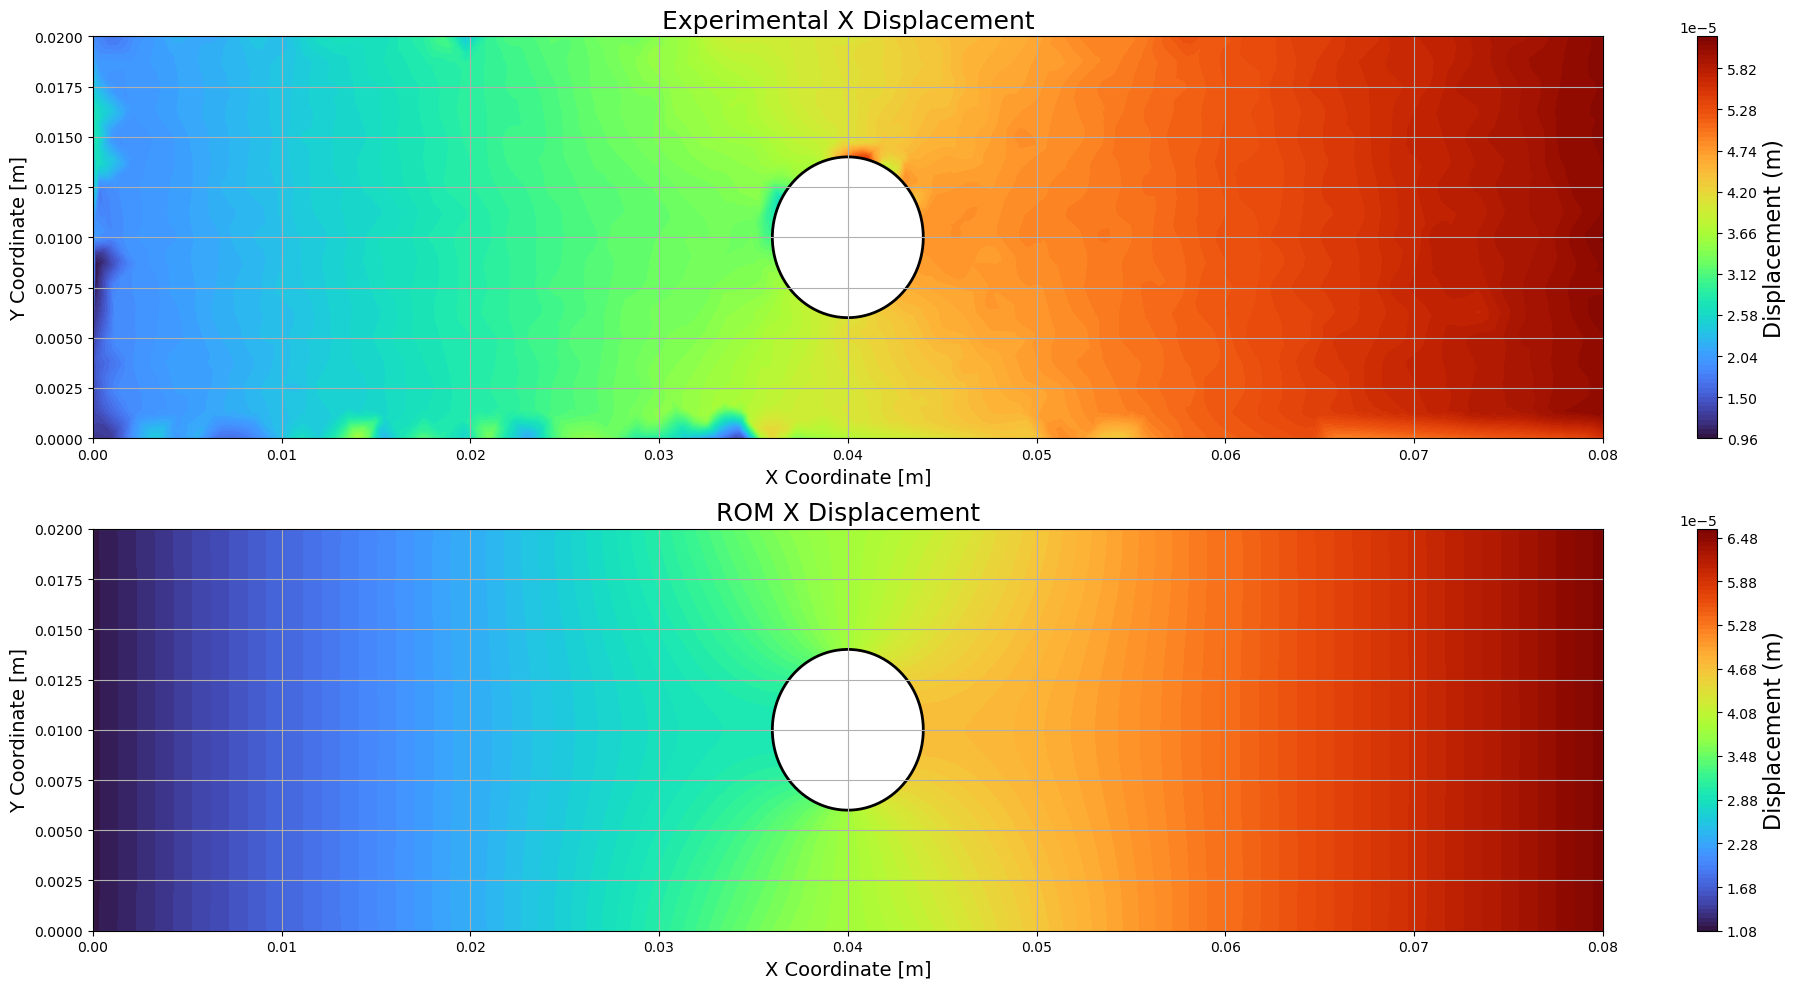

In [4]:
predicted_coeffs = surrogate.predict(result.G, result.K)
rom_ux, rom_uy = reconstruct_from_basis(basis, predicted_coeffs, len(node_x))

fig, _ = plot_fields(node_x, node_y, {"Experimental X Displacement": exp_ux, "ROM X Displacement": rom_ux})
plt.show()

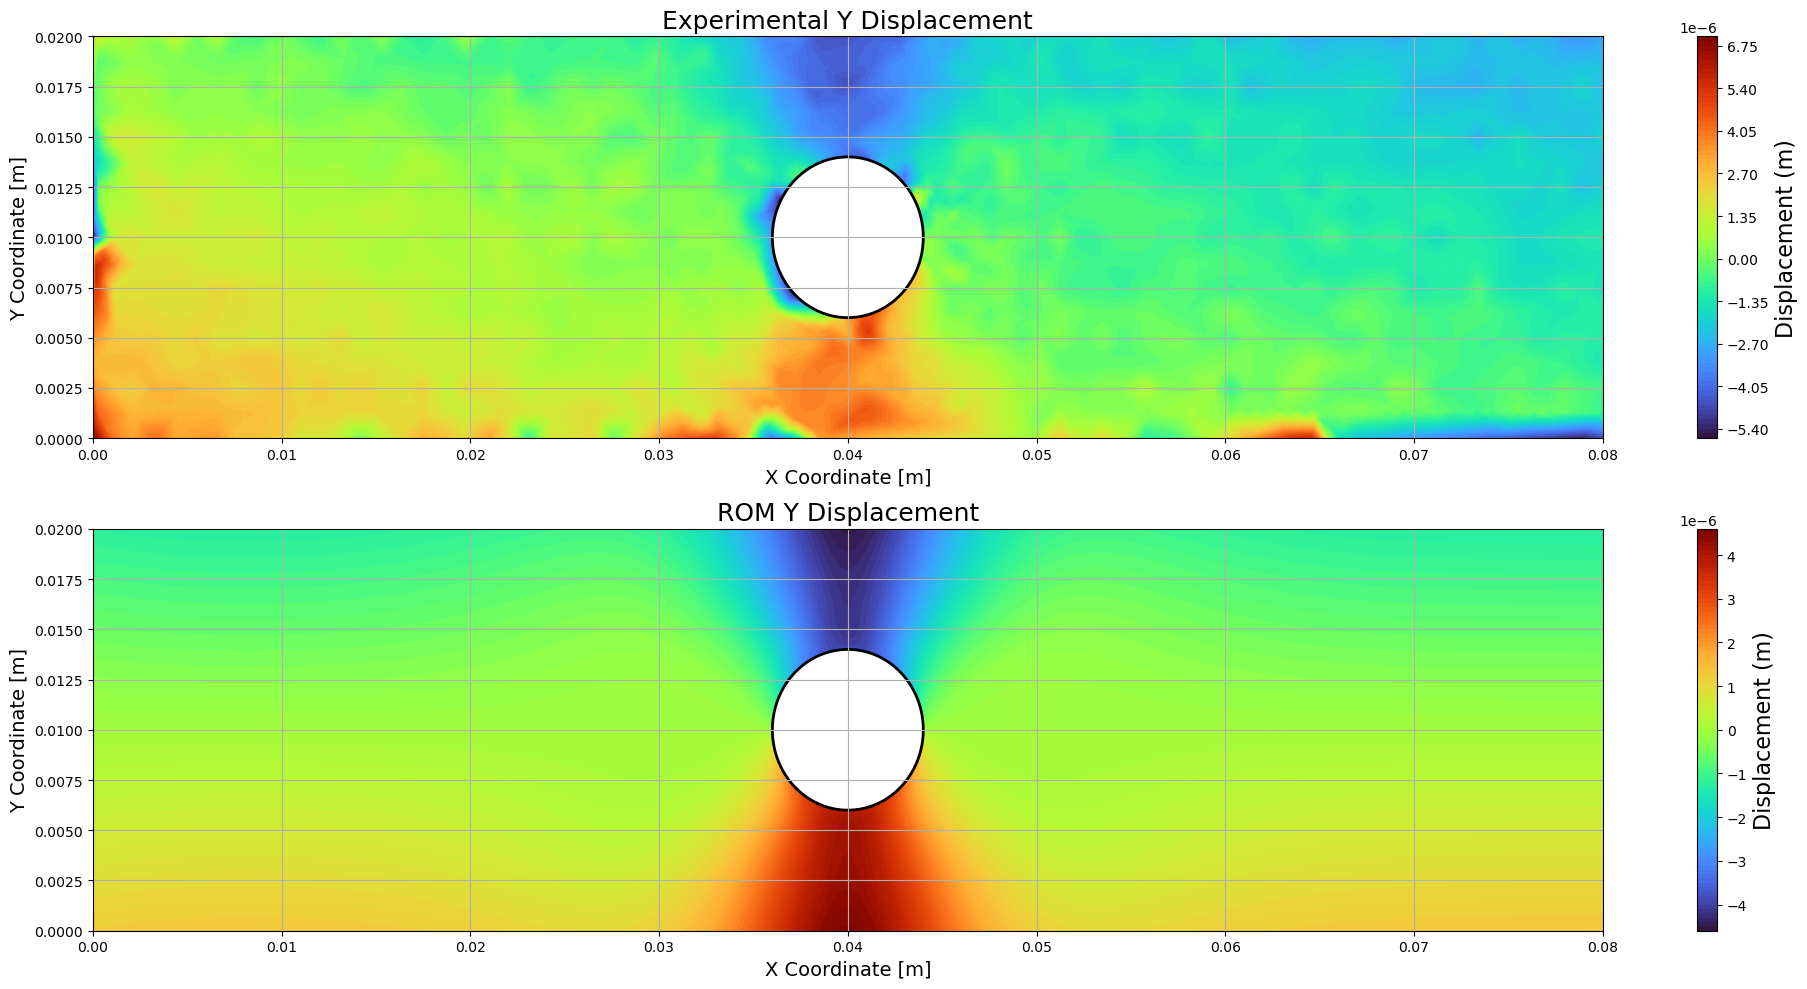

In [5]:
fig, _ = plot_fields(node_x, node_y, {"Experimental Y Displacement": exp_uy, "ROM Y Displacement": rom_uy})
plt.show()

## 4. (Reference) Solving the full-order model directly

This needs FEniCSx -- run it from the `fenicsx` conda environment
(`conda env create -f environment.yml`) if you want the ground-truth FOM
solve rather than the ROM surrogate. Not executed as part of this notebook's
saved output.

```python
from romid.fom import read_mesh, solve_fom

domain, cell_tags, facet_tags = read_mesh(str(DATA_DIR / "tensile_test_specimen.msh"))
_, _, domain_sub, u_sub = solve_fom(domain, facet_tags, G=result.G, K=result.K)
```

To rebuild the full snapshot matrix / POD basis / RBF surrogate from scratch
(rather than the 100-sample set shipped in `data/sample/`), see
`scripts/regenerate_data.py`.